# Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_excel('../data/suspension_experiments.xlsx', sheet_name=None)

In [4]:
df.keys()

dict_keys(['Протокол экспериментов', 'Суспензии', 'Подложки'])

In [5]:
df['Подложки']['Смачиваемость подложки'].unique()

array([nan, 'Лиофильная', 'Нейтральная', 'Лиофобная'], dtype=object)

In [6]:
df['Подложки']['Смачиваемость подложки'] = df['Подложки']['Смачиваемость подложки'].map(
        {
        'Лиофильная': 'lyophilic',
        'Нейтральная': 'neutral',
        'Лиофобная': 'lyophobic'
    }
)

In [7]:
df_susp_exp = pd.merge(pd.merge(
    df['Протокол экспериментов'], df['Суспензии'], 
    on="Код суспензии", how='left'
), df['Подложки'], on="Код подложки", how='left')
df_susp_exp = df_susp_exp[
    df_susp_exp['Тест №']!=1
]
df_susp_exp.head()

,Тест №,Код подложки,Код суспензии,"Напряжение, В","Длительность больших импульсов, мс","Высота генератора над подложкой, м","Угол наклона, °","Режим генерации [0 - капель нет, 1 - одиночная капля, 2 - несколько капель]","Диаметр капли, мм",Плотность среды,Поверхностное натяжение среды,Динамическая вязкость среды,Средний диаметр частиц,Соотношение плотности частиц и плотности среды,Концентрация (объёмная доля) частиц внутри капель,Смачиваемость подложки,Шероховатость поверхности подложки
4,2,черновая,S1,105.0,10.0,0.8,0,1.0,3.12,0.82,26.9,6.79,0.0415,1.219512,0.08,NaN,NaN
5,3,W1,S1,105.0,10.0,0.8,0,1.0,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
6,4,W1,S1,105.0,10.0,0.8,0,1.0,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
7,5,W1,S1,105.0,10.0,0.8,0,1.0,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
8,6,черновая,DS1,121.5,12.0,0.8,0,1.0,3.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df_data = pd.read_excel('../data/data_target.xlsx', index_col=[0])
df_data.head()

,Test #,Total number of dropped drops,splashing,breaking_up,net_impact,rebound
2,2,1,1,0,0,0
3,3,1,1,0,0,0
4,4,1,1,0,0,0
5,5,1,1,0,0,0
6,6,1,1,0,0,0


In [9]:
df_merged = df_data.merge(df_susp_exp, left_on='Test #', right_on='Тест №', how='left')
df_merged.head()

,Test #,Total number of dropped drops,splashing,breaking_up,net_impact,rebound,Тест №,Код подложки,Код суспензии,"Напряжение, В","Длительность больших импульсов, мс","Высота генератора над подложкой, м","Угол наклона, °","Режим генерации [0 - капель нет, 1 - одиночная капля, 2 - несколько капель]","Диаметр капли, мм",Плотность среды,Поверхностное натяжение среды,Динамическая вязкость среды,Средний диаметр частиц,Соотношение плотности частиц и плотности среды,Концентрация (объёмная доля) частиц внутри капель,Смачиваемость подложки,Шероховатость поверхности подложки
0,2,1,1,0,0,0,2,черновая,S1,105.0,10.0,0.8,0,1.0,3.12,0.82,26.9,6.79,0.0415,1.219512,0.08,NaN,NaN
1,3,1,1,0,0,0,3,W1,S1,105.0,10.0,0.8,0,1.0,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
2,4,1,1,0,0,0,4,W1,S1,105.0,10.0,0.8,0,1.0,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
3,5,1,1,0,0,0,5,W1,S1,105.0,10.0,0.8,0,1.0,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
4,6,1,1,0,0,0,6,черновая,DS1,121.5,12.0,0.8,0,1.0,3.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Преобразование режима генерации

In [10]:
df_merged['Режим генерации [0 - капель нет, 1 - одиночная капля, 2 - несколько капель]'].unique()

array([ 1.,  2., nan])

In [11]:
df_merged.rename(
    columns={
        'Режим генерации [0 - капель нет, 1 - одиночная капля, 2 - несколько капель]': 'Режим генерации'
    }, inplace=True
)

In [12]:
df_merged.loc[
    df_merged['Режим генерации']!=1,
    'Режим генерации'
] = 0

In [13]:
df_merged.columns

Index(['Test #', 'Total number of dropped drops', 'splashing', 'breaking_up',
       'net_impact', 'rebound', 'Тест №', 'Код подложки', 'Код суспензии',
       'Напряжение, В', 'Длительность больших импульсов, мс',
       'Высота генератора над подложкой, м', 'Угол наклона, °',
       'Режим генерации', 'Диаметр капли, мм', 'Плотность среды',
       'Поверхностное натяжение среды', 'Динамическая вязкость среды',
       'Средний диаметр частиц',
       'Соотношение плотности частиц и плотности среды',
       'Концентрация (объёмная доля) частиц внутри капель',
       'Смачиваемость подложки', 'Шероховатость поверхности подложки'],
      dtype='object')

In [14]:
df_merged[['Режим генерации', 'Total number of dropped drops']] = df_merged[['Режим генерации', 'Total number of dropped drops']].astype(int)

In [15]:
# mask = ~np.all(df_merged[['Режим генерации', 'Total number of dropped drops']], axis=1)
mask = df_merged['Режим генерации'] != df_merged['Total number of dropped drops']
df_merged[mask].shape

(6, 23)

In [16]:
df_merged['Режим генерации'].unique()

array([1, 0])

In [17]:
df_merged['Total number of dropped drops'].unique()

array([1, 0])

In [18]:
df_merged[
    (df_merged['Режим генерации']==0) &
    (df_merged['Total number of dropped drops']==1)
].shape

(0, 23)

In [19]:
df_merged[
    (df_merged['Режим генерации']==1) &
    (df_merged['Total number of dropped drops']==0)
].shape

(6, 23)

# Переименование колонок

In [20]:
df.keys()

dict_keys(['Протокол экспериментов', 'Суспензии', 'Подложки'])

In [21]:
df['Протокол экспериментов'].columns

Index(['Тест №', 'Код подложки', 'Код суспензии', 'Напряжение, В',
       'Длительность больших импульсов, мс',
       'Высота генератора над подложкой, м', 'Угол наклона, °',
       'Режим генерации [0 - капель нет, 1 - одиночная капля, 2 - несколько капель]',
       'Диаметр капли, мм'],
      dtype='object')

In [22]:
df_merged.columns

Index(['Test #', 'Total number of dropped drops', 'splashing', 'breaking_up',
       'net_impact', 'rebound', 'Тест №', 'Код подложки', 'Код суспензии',
       'Напряжение, В', 'Длительность больших импульсов, мс',
       'Высота генератора над подложкой, м', 'Угол наклона, °',
       'Режим генерации', 'Диаметр капли, мм', 'Плотность среды',
       'Поверхностное натяжение среды', 'Динамическая вязкость среды',
       'Средний диаметр частиц',
       'Соотношение плотности частиц и плотности среды',
       'Концентрация (объёмная доля) частиц внутри капель',
       'Смачиваемость подложки', 'Шероховатость поверхности подложки'],
      dtype='object')

In [23]:
new_names = ['test', 'substrate', 'suspension', 'voltage', 
             'long_impulse_duration', 'height', 'inclination', 
             'generation_mode', 'droplet_diameter'
]

dict_rename = {key: new_names[i] for i, key in enumerate(df['Протокол экспериментов'].columns)}
df_merged.rename(columns=dict_rename, inplace=True)

In [24]:
new_names = [
    'suspension', 'liquid_density', 'surface_tension', 
    'viscosity', 'particle_mean_diameter', 'particle_liquid_density_ratio', 
    'volume_fraction'
]
dict_rename = {key: new_names[i] for i, key in enumerate(df['Суспензии'].columns)}
df_merged.rename(columns=dict_rename, inplace=True)

In [25]:
new_names = [
    'substrate', 'wettability', 'roughness'
]
dict_rename = {key: new_names[i] for i, key in enumerate(df['Подложки'].columns)}
df_merged.rename(columns=dict_rename, inplace=True)

In [26]:
df_merged.head()

,Test #,Total number of dropped drops,splashing,breaking_up,net_impact,rebound,test,substrate,suspension,voltage,long_impulse_duration,height,inclination,Режим генерации,droplet_diameter,liquid_density,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,volume_fraction,wettability,roughness
0,2,1,1,0,0,0,2,черновая,S1,105.0,10.0,0.8,0,1,3.12,0.82,26.9,6.79,0.0415,1.219512,0.08,NaN,NaN
1,3,1,1,0,0,0,3,W1,S1,105.0,10.0,0.8,0,1,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
2,4,1,1,0,0,0,4,W1,S1,105.0,10.0,0.8,0,1,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
3,5,1,1,0,0,0,5,W1,S1,105.0,10.0,0.8,0,1,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
4,6,1,1,0,0,0,6,черновая,DS1,121.5,12.0,0.8,0,1,3.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
df_merged.rename(columns={'Total number of dropped drops': 'one_drop'}, inplace=True)

In [28]:
df_merged.columns

Index(['Test #', 'one_drop', 'splashing', 'breaking_up', 'net_impact',
       'rebound', 'test', 'substrate', 'suspension', 'voltage',
       'long_impulse_duration', 'height', 'inclination', 'Режим генерации',
       'droplet_diameter', 'liquid_density', 'surface_tension', 'viscosity',
       'particle_mean_diameter', 'particle_liquid_density_ratio',
       'volume_fraction', 'wettability', 'roughness'],
      dtype='object')

In [29]:
df_merged.drop('test', axis=1, inplace=True)
df_merged.rename(
    columns={
        'Test #': 'test'
    }, inplace=True
)

In [30]:
df_merged.to_excel('../data/df_merged.xlsx')

# Profiler

In [31]:
from pandas_profiling import ProfileReport

profile = ProfileReport(df_merged, title='Droplets EDA')
profile.to_file('../data/report.html')

C:\Users\dimaz\AppData\Local\Temp\ipykernel_13748\355716218.py:1: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Feature analysis

## Data understanding

In [2]:
df = pd.read_excel('../data/df_merged.xlsx', index_col=[0])

#### Data Preparation  2. b. ii. Пропуск в колонках liquid

In [3]:
mask = df['liquid_density'].isna()
df[mask]

,test,one_drop,splashing,breaking_up,net_impact,rebound,substrate,suspension,voltage,long_impulse_duration,...,Режим генерации,droplet_diameter,liquid_density,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,volume_fraction,wettability,roughness
4,6,1,1,0,0,0,черновая,DS1,121.5,12,...,1,3.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.drop(index=4, inplace=True)

### 2. b. ii. Построить завис. Droplet diameter от voltage в разрезе suspension

In [5]:
df.columns

Index(['test', 'one_drop', 'splashing', 'breaking_up', 'net_impact', 'rebound',
       'substrate', 'suspension', 'voltage', 'long_impulse_duration', 'height',
       'inclination', 'Режим генерации', 'droplet_diameter', 'liquid_density',
       'surface_tension', 'viscosity', 'particle_mean_diameter',
       'particle_liquid_density_ratio', 'volume_fraction', 'wettability',
       'roughness'],
      dtype='object')

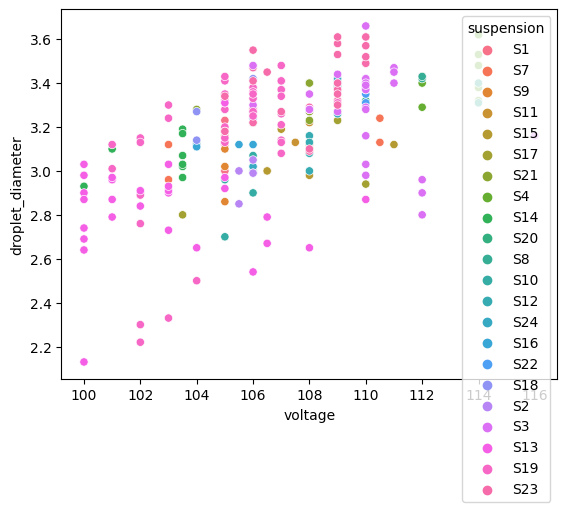

<Figure size 4000x4000 with 0 Axes>

In [6]:
sns.scatterplot(df, x='voltage', y='droplet_diameter', hue='suspension')
plt.figure(figsize=(40, 40))
plt.show()

#### UPD: объединить суспензии со схожими параметрами: по плотности, по вязкости и по поверхностному натяжению. Построить 3 графика вместо одного

In [7]:
sorted(df['liquid_density'].unique())

[0.82, 1.0, 1.06, 1.14, 1.18]

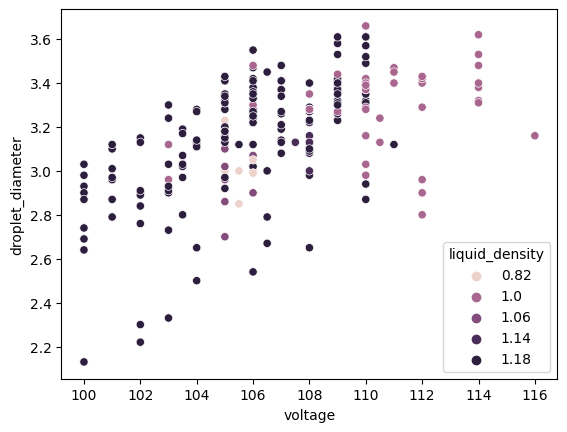

<Figure size 4000x4000 with 0 Axes>

In [8]:
sns.scatterplot(df, x='voltage', y='droplet_diameter', hue='liquid_density')
plt.figure(figsize=(40, 40))
plt.show()

In [9]:
sorted(df['viscosity'].unique())

[1.04, 2.05, 6.79, 6.89, 23.1]

In [10]:
df_temp = df.copy()
df_temp['viscocity_group'] = ''
df_temp['viscocity_group'] = df_temp['viscosity'].astype(str)
df_temp.loc[
    df_temp['viscocity_group'].isin(['6.79', '6.89']),
    'viscocity_group'
] = '6.79, 6.89'

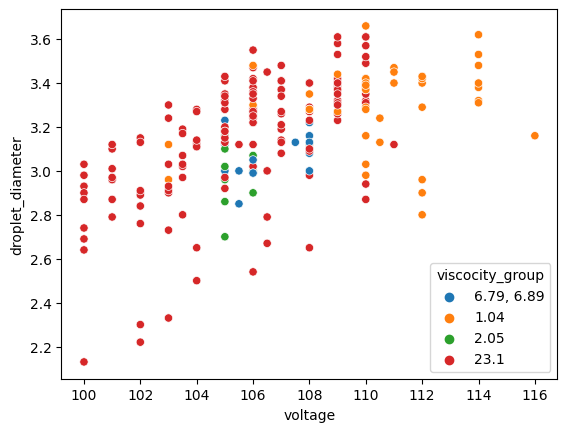

<Figure size 4000x4000 with 0 Axes>

In [11]:
sns.scatterplot(df_temp, x='voltage', y='droplet_diameter', hue='viscocity_group')
plt.figure(figsize=(40, 40))
plt.show()

In [12]:
sorted(df['surface_tension'].unique())

[26.9, 67.9, 69.1, 71.3, 73.2]

In [13]:
df_temp = df.copy()
df_temp['surface_tension_group'] = ''
df_temp['surface_tension_group'] = df_temp['surface_tension'].astype(str)
df_temp.loc[
    df_temp['surface_tension_group'].isin(['67.9', '69.1']),
    'surface_tension_group'
] = '67.9, 69.1'
df_temp.loc[
    df_temp['surface_tension_group'].isin(['71.3', '73.2']),
    'surface_tension_group'
] = '71.3, 73.2'

In [14]:
df_temp['surface_tension_group'].unique()

array(['26.9', '71.3, 73.2', '67.9, 69.1'], dtype=object)

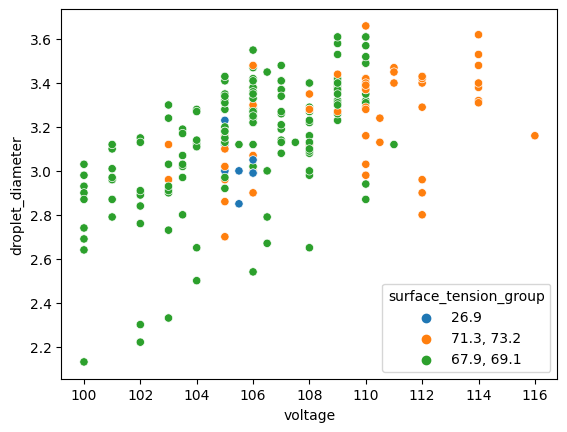

<Figure size 4000x4000 with 0 Axes>

In [15]:
sns.scatterplot(df_temp, x='voltage', y='droplet_diameter', hue='surface_tension_group')
plt.figure(figsize=(40, 40))
plt.show()

## Data preparation

### 1. b. i. Присутствуют черновые подложки в признаке substrate (дропаем черновую + other value)


In [16]:
df['substrate'].unique()

array(['черновая', 'W1', 'W2', 'W3',
       'черновая подложка W3 алюминиевая сторона', 'W4',
       'черновая подложка W3, сторона с покрытием'], dtype=object)

In [17]:
df_edited = df[
    ~df['substrate'].isin(['черновая', 
    'черновая подложка W3 алюминиевая сторона',
    'черновая подложка W3, сторона с покрытием'])
].copy()

### 1. b. iii. Long_imp_dur - возможно стоит объединить 18 и 21 -> 15

UPD: 1. первоначальный Long_imp_dur откатываем к оригиналу, отменяем перевод 18 и 21 в 15!!!
2. Long_imp_dur_binary = 15, 18, 21 -> high; 10, 12 -> low

In [18]:
df_edited['long_impulse_duration'].unique()

array([10, 18, 21, 15, 12], dtype=int64)

In [19]:
# df_edited.loc[
#     df['long_impulse_duration'].isin([18, 21]),
#     'long_impulse_duration'
# ] = 15

In [20]:
df_edited.loc[
    df_edited['long_impulse_duration'].isin([15, 18, 21]),
    'long_impulse_dur_binary'
] = 'high'
df_edited.loc[
    df_edited['long_impulse_duration'].isin([10, 12]),
    'long_impulse_dur_binary'
] = 'low'

In [21]:
df_edited['long_impulse_dur_binary'].value_counts()

low     224
high    148
Name: long_impulse_dur_binary, dtype: int64

### 1. b. iv. Дропаем режим генерации

In [22]:
df_edited.drop(columns=['Режим генерации'], axis=1, inplace=True)

### 2. a. i. Droplet_diameter - , зап-е можно вести по признакам suspension, voltage, long impulse duration, height. Есть подобный метод в fillna. Следующий метод - fillna(ffill), пропуски можно заполнить предыд. Зн-ми.

In [23]:
df_edited.columns

Index(['test', 'one_drop', 'splashing', 'breaking_up', 'net_impact', 'rebound',
       'substrate', 'suspension', 'voltage', 'long_impulse_duration', 'height',
       'inclination', 'droplet_diameter', 'liquid_density', 'surface_tension',
       'viscosity', 'particle_mean_diameter', 'particle_liquid_density_ratio',
       'volume_fraction', 'wettability', 'roughness',
       'long_impulse_dur_binary'],
      dtype='object')

In [24]:
df_dr_diam = df_edited[
    [
        'suspension', 'voltage', 
        'long_impulse_duration', 'height', 'droplet_diameter'
     ]
]
df_dr_diam_nodup = df_dr_diam.drop_duplicates()
print(f'Количество дубликатов: {df_dr_diam.shape[0]-df_dr_diam_nodup.shape[0]}')

Количество дубликатов: 91


UPD:
Первые две итерации заполнения на оригинальной колонке Long_imp_dur (без объединения 18 и 21 в 15) 

1. Переделать первую итерацию, сделав на Suspension, Voltage и Impulse duration (без height!!)
2. ввести вторую итерацию заполнений средним, воспользовавшись теперь только колонками suspension, и long_impulse_duration. 
3. Затем нужно вывести оставшиеся пропуски и, если они есть, заполнить, воспользовавшись только средним по колонке suspension. 

Первая итерация

In [25]:
df_drop_mean = pd.DataFrame(
    df_dr_diam.drop_duplicates().dropna().groupby(
    [   
        'suspension', 'voltage', 
        'long_impulse_duration'
    ]
)['droplet_diameter'].mean()).reset_index()
df_drop_mean.head()

,suspension,voltage,long_impulse_duration,droplet_diameter
0,S1,105.0,10,3.1200
1,S10,105.0,15,2.8300
2,S10,106.0,12,2.9975
3,S11,107.5,10,3.1300
4,S11,108.0,10,3.1300


In [26]:
def fill_drop_diameter(df, df_drop_mean, params):
    df_copy = df.copy()
    df_na = df_copy[df_copy['droplet_diameter'].isna()]
    df_temp = df_na.merge(
        df_drop_mean,
        left_on=params,
        right_on=params,
        how='left'
    )
    df_temp['droplet_diameter'] = df_temp['droplet_diameter_x']\
        .fillna(df_temp['droplet_diameter_y'])
    df_temp.drop(columns=['droplet_diameter_x', 'droplet_diameter_y'], inplace=True)
    df_copy.loc[
        df_copy['test'].isin(df_temp['test']),
        'droplet_diameter'
    ] = df_temp['droplet_diameter']
    return df_copy

In [27]:
params = [   
        'suspension', 'voltage', 
        'long_impulse_duration'
    ]
df_edited = fill_drop_diameter(df_edited, df_drop_mean, params)

In [28]:
# индексы isna и предыдущие значения
def get_na_indexes(df_edited):
    indexes_isna = df_edited[df_edited['droplet_diameter'].isna()].index
    all_indexes = sorted(list(set(np.hstack([[i-1, i] for i in indexes_isna]))))
    indexes = sorted(list(set(all_indexes) & set(df_edited.index)))
    return indexes

In [29]:
try:
    indexes = get_na_indexes(df_edited)
    display(HTML(pd.DataFrame(df_edited.loc[indexes]['droplet_diameter']).head().to_html()))
    df_edited.loc[indexes].to_excel('../data/df_na_first.xlsx')
except ValueError:
    pass
print(f"Осталось пропусков: {df_edited['droplet_diameter'].isna().sum()}")

,droplet_diameter
10,NaN
16,3.035
17,NaN
19,3.240
20,NaN


Осталось пропусков: 94


2. ввести вторую итерацию заполнений средним, воспользовавшись теперь только колонками suspension, и long_impulse_duration. 

In [30]:
params = [   
        'suspension',
        'long_impulse_duration'
    ]
df_edited = fill_drop_diameter(df_edited, df_drop_mean, params)

In [31]:
try:
    indexes = get_na_indexes(df_edited)
    display(HTML(pd.DataFrame(df_edited.loc[indexes]['droplet_diameter']).head().to_html()))
    df_edited.loc[indexes].to_excel('../data/df_na_second.xlsx')
except ValueError:
    pass
print(f"Осталось пропусков: {df_edited['droplet_diameter'].isna().sum()}")

Осталось пропусков: 0


3. Затем нужно вывести оставшиеся пропуски и, если они есть, заполнить, воспользовавшись только средним по колонке suspension. 

In [32]:
params = [   
        'suspension'
    ]
df_edited = fill_drop_diameter(df_edited, df_drop_mean, params)

In [33]:
try:
    indexes = get_na_indexes(df_edited)
    display(HTML(pd.DataFrame(df_edited.loc[indexes]['droplet_diameter']).head().to_html()))
    df_edited.loc[indexes].to_excel('../data/df_na_third.xlsx')
except ValueError:
    pass
print(f"Осталось пропусков: {df_edited['droplet_diameter'].isna().sum()}")

Осталось пропусков: 0


### 2. a. ii. Part liq des rat - про missing в liquid смотри выше

### 2.b.i. Исправить ошибки и кодировки
roughness - Обработка прочерков (пропуск). Есть таблица с пропущ. Шероховатостями:

UPD: 
таблица выслана в telegram.

Ввести roughness_binary: 1 для roughness >10 (то есть только для W4 - 10.89) и 0 для всех остальных (W1-W3)


In [34]:
df_roughness = pd.read_excel('../data/Substrates.xlsx')

In [35]:
df_roughness

,Substrate Code,Wettability,Roughness
0,W1,Hydrophilic,0.10
1,W2,Neutral,0.04
2,W3,Hydrophobic,2.49
3,W4,Hydrophilic,10.89


In [36]:
df_edited[['substrate', 'wettability']].drop_duplicates()

,substrate,wettability
1,W1,lyophilic
5,W2,neutral
8,W3,lyophobic
10,W4,lyophilic


In [37]:
df_edited['roughness'].value_counts()

-        225
0.1      104
10.89     43
Name: roughness, dtype: int64

In [38]:
df_edited['roughness'].unique()

array([0.1, '-', 10.89], dtype=object)

In [39]:
df_edited['substrate'].unique()

array(['W1', 'W2', 'W3', 'W4'], dtype=object)

In [40]:
df_edited.loc[
    df_edited['substrate']=='W2',
    'roughness'
] = 0.04
df_edited.loc[
    df_edited['substrate']=='W3',
    'roughness'
] = 2.49

In [41]:
df_edited['roughness'].value_counts()

0.04     114
2.49     111
0.10     104
10.89     43
Name: roughness, dtype: int64

In [42]:
df_edited['roughness'] = df_edited['roughness'].astype(float)
df_edited['roughness_binary'] = 0
df_edited.loc[
    (df_edited['roughness'])>10,
    'roughness_binary'
] = 1

In [43]:
df_edited['roughness_binary'].value_counts()

0    329
1     43
Name: roughness_binary, dtype: int64

### 2.b.i 3. Перевести единицы измерения в СИ

In [44]:
df_edited.columns

Index(['test', 'one_drop', 'splashing', 'breaking_up', 'net_impact', 'rebound',
       'substrate', 'suspension', 'voltage', 'long_impulse_duration', 'height',
       'inclination', 'droplet_diameter', 'liquid_density', 'surface_tension',
       'viscosity', 'particle_mean_diameter', 'particle_liquid_density_ratio',
       'volume_fraction', 'wettability', 'roughness',
       'long_impulse_dur_binary', 'roughness_binary'],
      dtype='object')

In [45]:
df_edited['droplet_diameter'] = df_edited['droplet_diameter'] / 1000
df_edited['surface_tension'] = df_edited['surface_tension'] / 1000
df_edited['liquid_density'] = df_edited['liquid_density'] * 1000
df_edited['viscosity'] = df_edited['viscosity'] / 1000 
df_edited['particle_mean_diameter'] = df_edited['particle_mean_diameter'] / 1000

### 2. c. i. Volume fraction - объединить 0.04 и 0.05, а также 0.08 и 0.1


In [46]:
df_edited['volume_fraction'].unique()

array([0.08, 0.1 , 0.04, 0.05])

In [47]:
df_edited['volume_fraction_binary'] = 0
df_edited.loc[
    df_edited['volume_fraction'].isin([0.08, 0.1]),
    'volume_fraction_binary'
] = 1

In [48]:
df_edited['volume_fraction_binary'].value_counts()

1    271
0    101
Name: volume_fraction_binary, dtype: int64

### 3. a. Обезразмеривание с учётом физичности задачи в новых признаках (Re, We, и т.д.)

$velocity=f(height)=\sqrt{2g \cdot height}$

In [49]:
from scipy.constants import g

In [50]:
df_edited['height'].unique()

array([0.8, 0.2, 1.8])

In [51]:
velocity = np.sqrt(2*g*df_edited['height'])

$Re=\frac{velocity \cdot droplet\_diameter \cdot liquid\_density}{viscosity}$

In [52]:
df_edited['velocity'] = velocity

In [53]:
df_edited.columns

Index(['test', 'one_drop', 'splashing', 'breaking_up', 'net_impact', 'rebound',
       'substrate', 'suspension', 'voltage', 'long_impulse_duration', 'height',
       'inclination', 'droplet_diameter', 'liquid_density', 'surface_tension',
       'viscosity', 'particle_mean_diameter', 'particle_liquid_density_ratio',
       'volume_fraction', 'wettability', 'roughness',
       'long_impulse_dur_binary', 'roughness_binary', 'volume_fraction_binary',
       'velocity'],
      dtype='object')

In [54]:
df_edited['Re'] = (velocity * df_edited['droplet_diameter']\
                    * df_edited['liquid_density']) / df_edited['viscosity']

$We=\frac{velocity^2 \cdot droplet\_diameter \cdot liquid\_density}{surface\_tension}$

In [55]:
df_edited['We'] = ((velocity ** 2) * df_edited['droplet_diameter']\
                    * df_edited['liquid_density']) / df_edited['surface_tension']

$We\_Re=We^{1/2}Re^{1/4}$

In [56]:
df_edited['We_Re'] = (df_edited['We'] ** (1/2)) * (df_edited['Re'] ** (1/4))

particle_droplet_diameter_ratio 

In [57]:
df_edited['particle_droplet_diameter_ratio'] = df_edited['particle_mean_diameter'] / df_edited['droplet_diameter']

In [58]:
particle_diameter_cat = {
    'small': 0.0415/1000,
    'medium': 0.1375/1000,
    'large': 0.275/1000
}

In [59]:
df_edited['particle_diameter_cat'] = df_edited['particle_mean_diameter'].map(
    {v:k for k, v in particle_diameter_cat.items()}
)

### Удаляем признаки 'substrate', 'suspension'

In [61]:
df_edited.drop(columns=['substrate', 'suspension'], inplace=True)

### 3. c. Кодирование категориальных признаков
Liquid density, surface tension, viscosity, particle mean diam - Ordinal encoder
Wettability - ordinal enc

In [62]:
# from sklearn.preprocessing import OrdinalEncoder

In [63]:
# df_edited.columns

In [64]:
# enc = OrdinalEncoder()
# df_edited[
#         [
#         'liquid_density', 'surface_tension',
#         'viscosity', 'particle_mean_diameter'
#     ]
# ] = enc.fit_transform(
#     df_edited[
#     [
#         'liquid_density', 'surface_tension',
#         'viscosity', 'particle_mean_diameter'
#     ]
# ])

# Сохранение обновленного датасета и создание Pandas-profiling

In [65]:
df_edited.to_excel('../data/df_merged_edited.xlsx')

In [66]:
from pandas_profiling import ProfileReport

profile = ProfileReport(df_edited, title='Droplets EDA')
profile.to_file('../data/report_edited.html')

C:\Users\dimaz\AppData\Local\Temp\ipykernel_6784\2131132279.py:1: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Data Understanding

## 1. Построить корреляции по Спирмену и Мэтьюсу всех факторов с целевыми признаками. 
a. Построить высокие корреляции (>0.7) для борьбы с мультиколлинеарностью (можно наложить фильтрацию на df.corr)

b. Отдельно вывести корреляции по Спирмену и Мэтьюсу между volume_fraction_binary, particle_liquid_density_ratio, particle_mean_diameter, wettability, roughness_binary, inclination и типом соударения (на 4 целевых признака, без one_drop). 


In [116]:
from sklearn.metrics import matthews_corrcoef

In [117]:
df = pd.read_excel('../data/df_merged_edited.xlsx', index_col=[0])

In [118]:
target_columns = ['splashing', 'breaking_up', 'net_impact', 'rebound']
features = list(set(df.columns) - set(target_columns + ['test']))

In [119]:
df_corr = df[features].corr()

C:\Users\dimaz\AppData\Local\Temp\ipykernel_6784\3002195822.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_corr = df[features].corr()


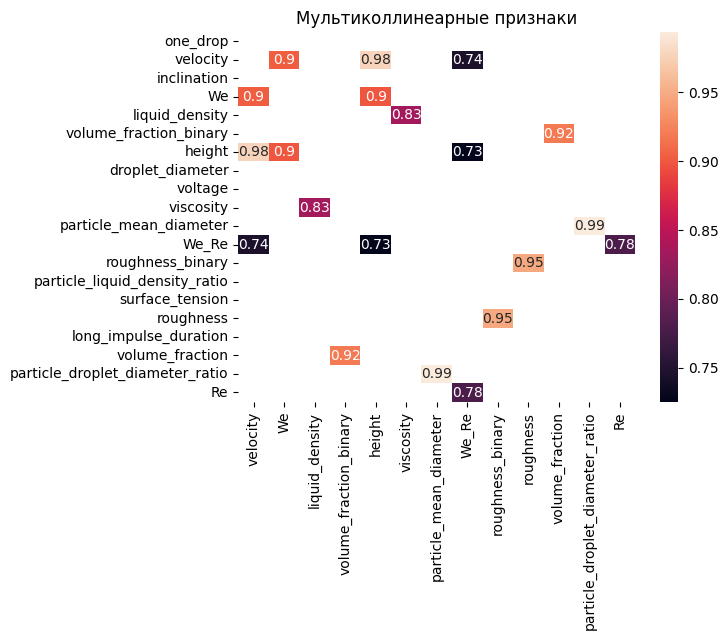

In [120]:
df_temp = df_corr[(df_corr>=0.7) & (df_corr!=1)]
df_temp.dropna(axis=1, how='all', inplace=True)
sns.heatmap(df_temp, annot=True)
plt.title('Мультиколлинеарные признаки')
plt.show()

In [121]:
def plot_corr_spearman(df, target, features, filter=None):
    df_corr = pd.DataFrame(
        df[features+[target]].corr()[target]
    ).iloc[:-1]
    if filter is not None:
        mask = df_corr[target] > filter
        if df_corr[mask].shape[0]>0:
            df_corr = df_corr[mask]
        else:
            print(f'Корреляций для таргета\t {target} с порогом\t {filter} нет')
            return None
    df_corr.sort_values(by=target, inplace=True, ascending=False)
    sns.heatmap(df_corr, annot=True)
    plt.title(f'{target}')
    plt.show()

C:\Users\dimaz\AppData\Local\Temp\ipykernel_6784\4163087170.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df[features+[target]].corr()[target]


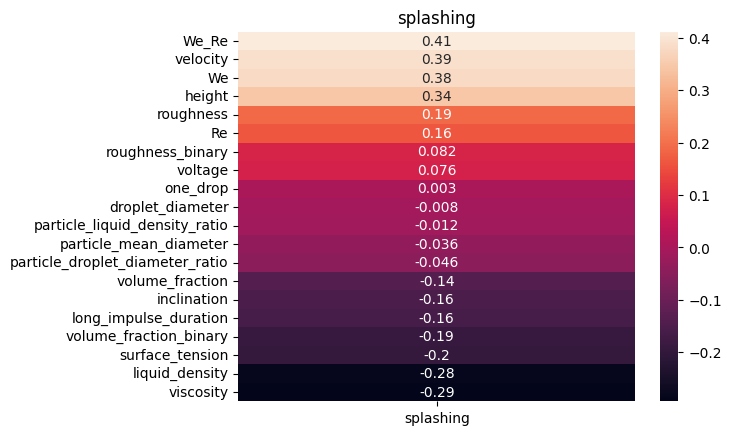

C:\Users\dimaz\AppData\Local\Temp\ipykernel_6784\4163087170.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df[features+[target]].corr()[target]


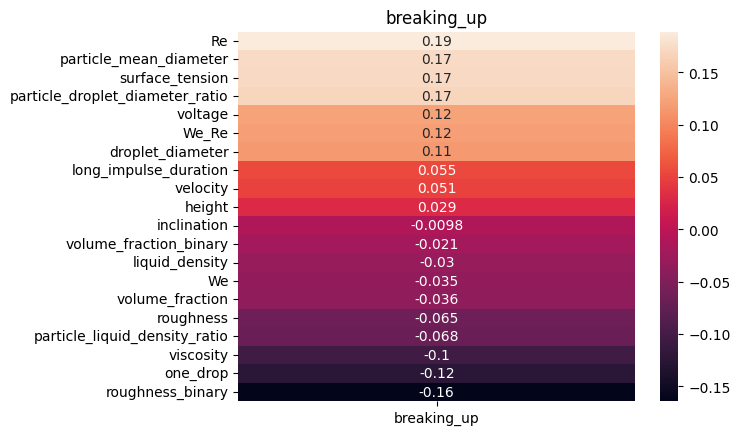

C:\Users\dimaz\AppData\Local\Temp\ipykernel_6784\4163087170.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df[features+[target]].corr()[target]


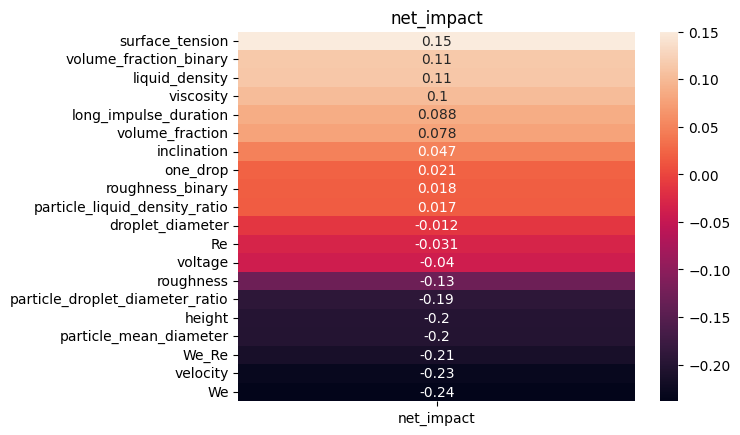

C:\Users\dimaz\AppData\Local\Temp\ipykernel_6784\4163087170.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df[features+[target]].corr()[target]


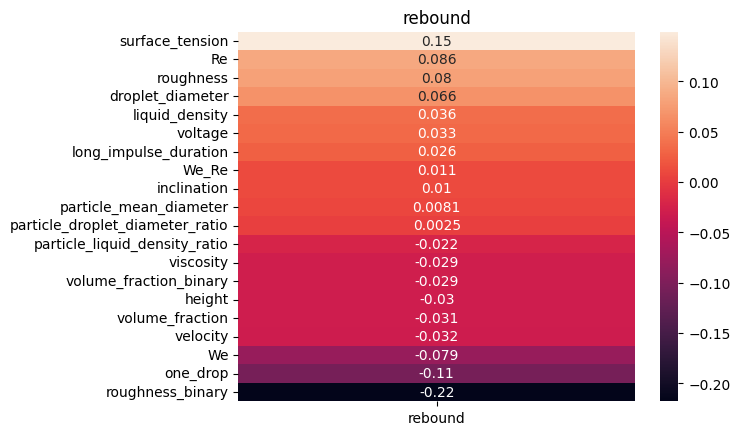

In [122]:
display(HTML('<h1>Корреляция Спирмена</h1>'))
for target in target_columns:
    plot_corr_spearman(df, target, features)

In [123]:
display(HTML('<h1>Корреляция Спирмена</h1>'))
for target in target_columns:
    plot_corr_spearman(df, target, features, filter=0.7)

Корреляций для таргета	 splashing с порогом	 0.7 нет
Корреляций для таргета	 breaking_up с порогом	 0.7 нет
Корреляций для таргета	 net_impact с порогом	 0.7 нет
Корреляций для таргета	 rebound с порогом	 0.7 нет


C:\Users\dimaz\AppData\Local\Temp\ipykernel_6784\4163087170.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df[features+[target]].corr()[target]
C:\Users\dimaz\AppData\Local\Temp\ipykernel_6784\4163087170.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df[features+[target]].corr()[target]
C:\Users\dimaz\AppData\Local\Temp\ipykernel_6784\4163087170.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df[features+[target]].corr()[target]
C:\Users\dimaz\AppData\Local\Temp\

In [124]:
def plot_corr_mathews(df, target, features, filter=None):
    df_corr = pd.DataFrame(index=[target])
    for feature in features:
        corr_coeff = matthews_corrcoef(
            df[feature].astype(str), df[target].astype(str)
        )
        df_corr[feature] = corr_coeff
    
    df_corr = df_corr.T
    df_corr.sort_values(by=target, inplace=True, ascending=False)
    df_corr = df_corr[df_corr[target]!=0]
    if filter is not None:
        mask = df_corr[target] > filter
        if df_corr[mask].shape[0]>0:
            df_corr = df_corr[mask]
        else:
            print(f'Корреляций для таргета\t {target} с порогом\t {filter} нет')
            return None
    display(HTML(f'<h1>{target}</h1>'))
    sns.heatmap(df_corr, annot=True)
    plt.title(f'{target}')
    plt.show()

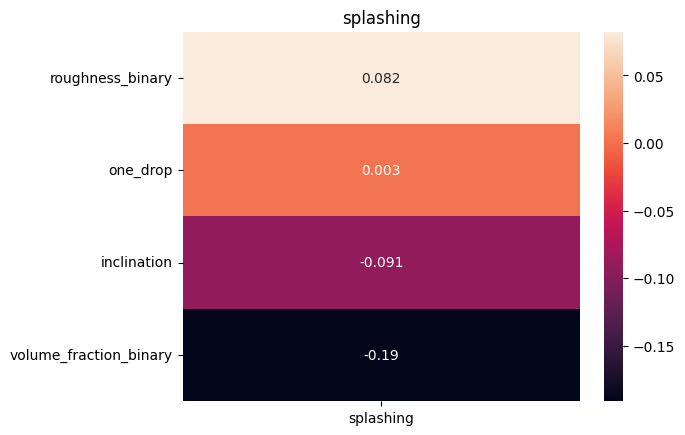

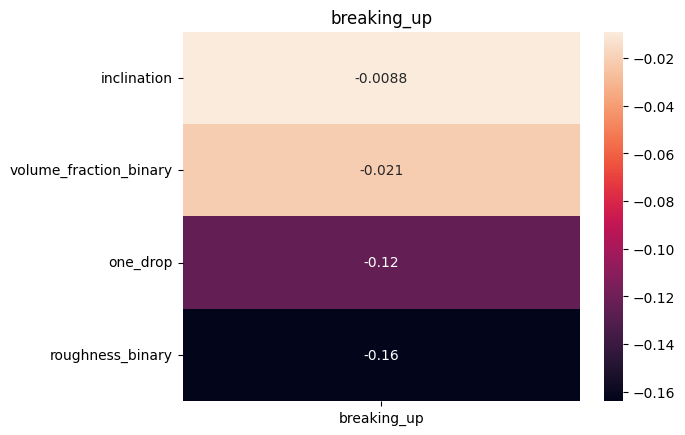

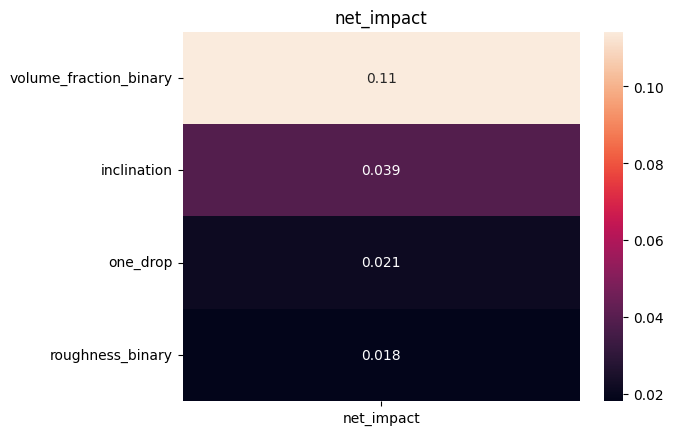

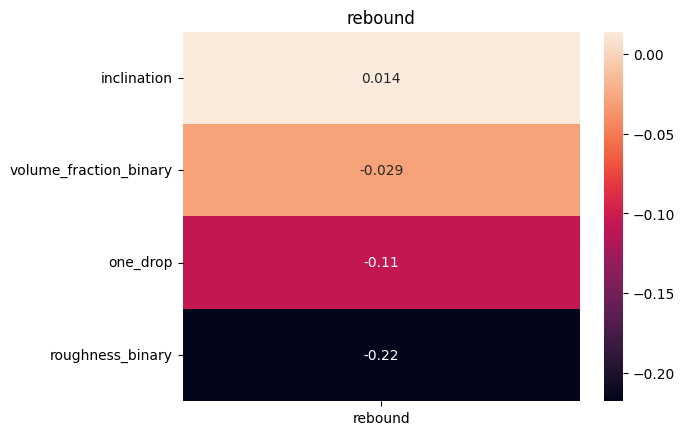

In [125]:
display(HTML('<h1>Корреляция Мэтьюса<h1>'))
print()
for target in target_columns:
    plot_corr_mathews(df, target, features)

In [126]:
display(HTML('<h1>Корреляция Мэтьюса<h1>'))
print()
for target in target_columns:
    plot_corr_mathews(df, target, features, filter=0.7)


Корреляций для таргета	 splashing с порогом	 0.7 нет
Корреляций для таргета	 breaking_up с порогом	 0.7 нет
Корреляций для таргета	 net_impact с порогом	 0.7 нет
Корреляций для таргета	 rebound с порогом	 0.7 нет


In [127]:
df.columns

Index(['test', 'one_drop', 'splashing', 'breaking_up', 'net_impact', 'rebound',
       'voltage', 'long_impulse_duration', 'height', 'inclination',
       'droplet_diameter', 'liquid_density', 'surface_tension', 'viscosity',
       'particle_mean_diameter', 'particle_liquid_density_ratio',
       'volume_fraction', 'wettability', 'roughness',
       'long_impulse_dur_binary', 'roughness_binary', 'volume_fraction_binary',
       'velocity', 'Re', 'We', 'We_Re', 'particle_droplet_diameter_ratio',
       'particle_diameter_cat'],
      dtype='object')

In [128]:
features = [
    'volume_fraction_binary', 'particle_liquid_density_ratio', 
    'particle_mean_diameter', 'wettability', 'roughness_binary', 
    'inclination'
]

C:\Users\dimaz\AppData\Local\Temp\ipykernel_6784\4163087170.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df[features+[target]].corr()[target]


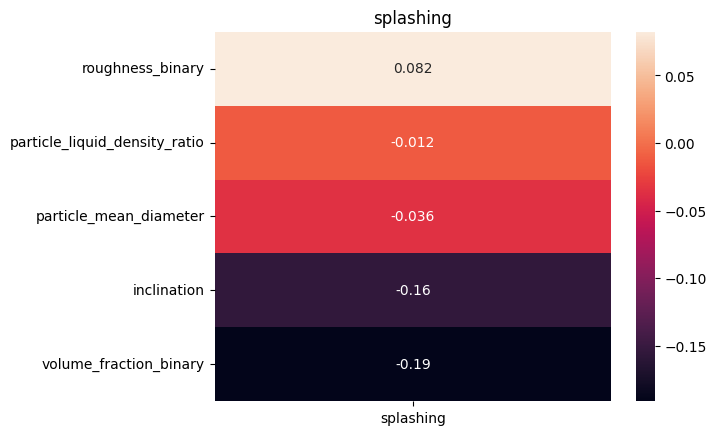

C:\Users\dimaz\AppData\Local\Temp\ipykernel_6784\4163087170.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df[features+[target]].corr()[target]


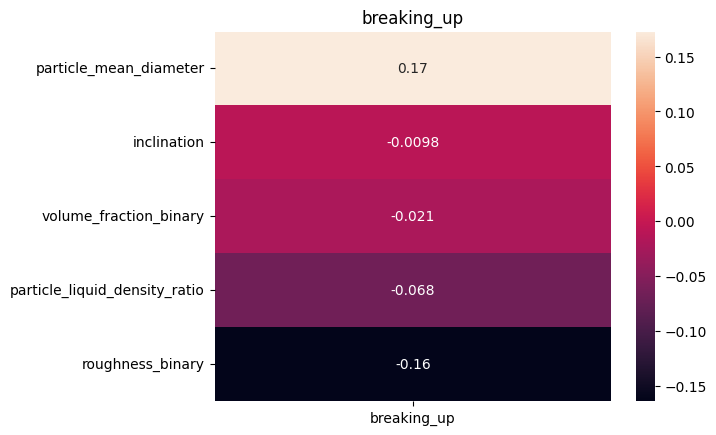

C:\Users\dimaz\AppData\Local\Temp\ipykernel_6784\4163087170.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df[features+[target]].corr()[target]


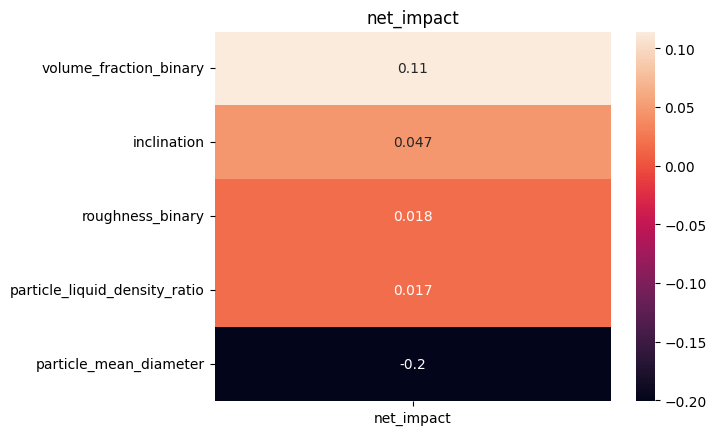

C:\Users\dimaz\AppData\Local\Temp\ipykernel_6784\4163087170.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df[features+[target]].corr()[target]


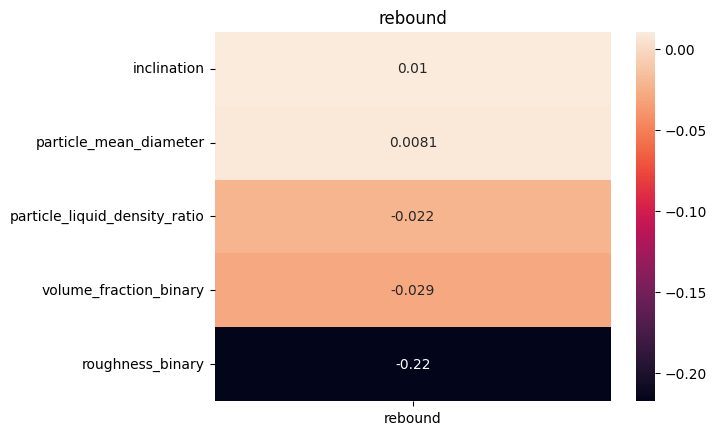

In [129]:
display(HTML('<h1>Корреляция Спирмена</h1>'))
for target in target_columns:
    plot_corr_spearman(df, target, features=features)

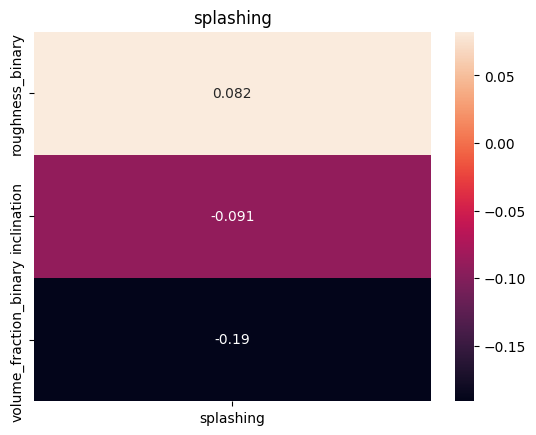

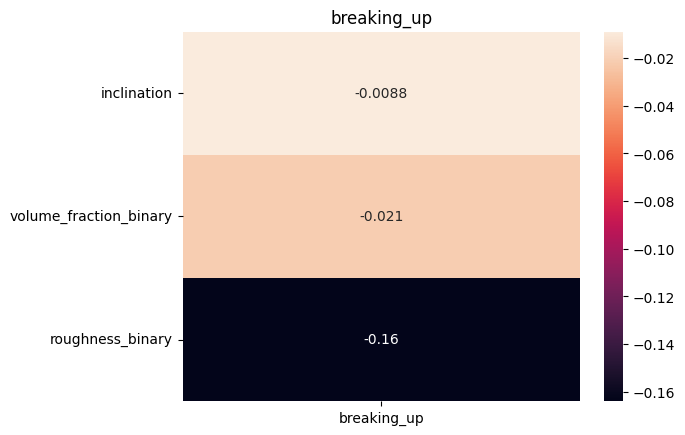

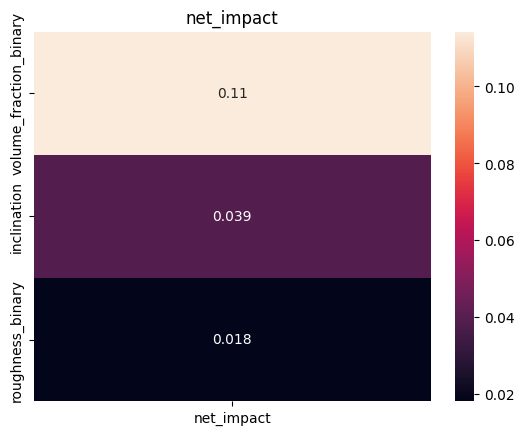

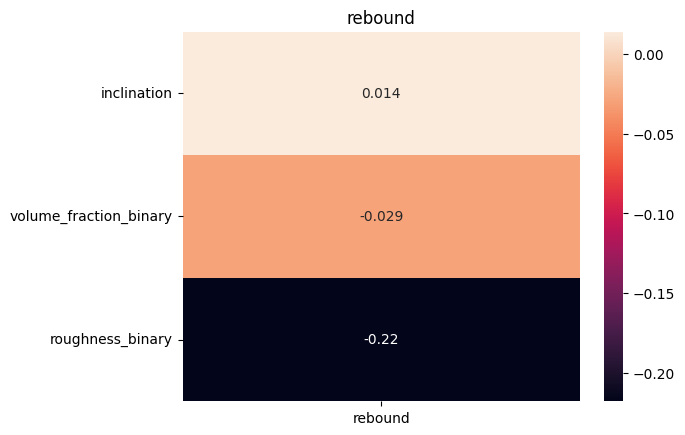

In [130]:
display(HTML('<h1>Корреляция Спирмена</h1>'))
for target in target_columns:
    plot_corr_mathews(df, target, features=features)

## 2. Отдельно ещё оценить влияние roughness_binary на тип соударения, когда wettability == lyophilic. 

Для этого можно построить сгруппированную столбчатую диаграмму (hue по roughness_binary, а по X - четыре группы по типам соударения splashing, breaking_up, net_impact, rebound). Всего 8 столбцов сгруппированных по 4. 

НО!, столбчатые диаграммы строить не в абсолютных количествах, а в относительных. Стандартная полная нормализация не подойдёт, нужно нормализировать таким образом, чтобы сумма по всем типам соударения была равна 1 для каждого значения roughness_binary (или другого исследуемого признака в п.3). Для этого, можно использовать value_counts(normalize=True) для отфильтрованных roughness_binary == 0 и roughness_binary == 1. То есть будет два результата value_counts. В общем случае фильтрация проводится для всех уникальных значений фактора (для п.3).


In [131]:
df_plot = df[df['wettability']=='lyophilic'].copy()

In [132]:
df_zero = pd.DataFrame(df_plot[
    df_plot['roughness_binary']==0
][target_columns].value_counts(normalize=True))
df_one = pd.DataFrame(df_plot[
    df_plot['roughness_binary']==1
][target_columns].value_counts(normalize=True))

In [133]:
df_zero

,,,,0
splashing,breaking_up,net_impact,rebound,
0,0,1,0,0.500000
1,0,0,0,0.298077
0,1,0,0,0.192308
1,1,0,0,0.009615


In [134]:
df_one

0
splashing breaking_up net_impact rebound          
1         0           0          0        0.581395
0         0           1          0        0.348837
          1           0          0        0.069767

In [135]:
df_one.rename(columns={0: 1}, inplace=True)
df_zero.reset_index(inplace=True)
df_one.reset_index(inplace=True)

In [136]:
df_roughness = df_zero.merge(
    df_one,
    how='left',
    right_on=['splashing', 'breaking_up', 'net_impact', 'rebound'],
    left_on=['splashing', 'breaking_up', 'net_impact', 'rebound']
).fillna(0)
df_roughness.style.background_gradient(
    axis=0, 
    subset=[0, 1],  
    cmap='YlOrRd'
)

,splashing,breaking_up,net_impact,rebound,0,1
0,0,0,1,0,0.500000,0.348837
1,1,0,0,0,0.298077,0.581395
2,0,1,0,0,0.192308,0.069767
3,1,1,0,0,0.009615,0.000000


In [137]:
df_plot['rebound'].unique()

array([0], dtype=int64)

## 3. Повторить предыдущий пункт (но без условия wettability == lyophilic), для оценки влияния следующих факторов на тип соударения: volume_fraction_binary, particle_liquid_density_ratio, particle_mean_diameter, wettability и inclination 

In [138]:
df_plot = df.copy()

In [139]:
features = [
    'volume_fraction_binary', 
    'particle_liquid_density_ratio', 
    'particle_mean_diameter', 
    'particle_diameter_cat',
    'wettability',
    'inclination',
    'roughness_binary'
]
df_plot = df_plot[features+target_columns]

In [140]:
for feature in features:
    display(HTML(f'<h1>{feature}</h1>'))
    df_feature = pd.DataFrame()
    unique_values = df_plot[feature].unique()
    dfs = []
    to_repl = []
    for value in unique_values:
        df_temp = pd.DataFrame(df_plot[
            df_plot[feature]==value
        ][target_columns].value_counts(normalize=True))
        df_temp['feature_value'] = [value for _ in range(df_temp.shape[0])]
        df_temp.reset_index(inplace=True)
        if type(value)==float or type(value)==np.float64:
            value = np.round(value, 4)
        to_repl.append(f"Доля {value}")
        df_temp.rename(columns={
            0: f"Доля {value}"}, inplace=True)
        dfs.append(df_temp)
    dfs = sorted(dfs, key=lambda x: x.shape[0], reverse=True)
    for i, df_ in enumerate(dfs):
        if i==0:
            df_feature = df_.copy()
            df_feature
        else:
            df_feature = df_feature.merge(
                df_,
                how='outer',
                right_on=target_columns,
                left_on=target_columns
            )
    columns_to_rename = [x for x in df_feature.columns if '0_' in str(x)]     
    df_feature.drop(columns=[x for x in df_feature.columns if 'feature_value' in x], inplace=True)
    df_feature.fillna(0, inplace=True)
    df_feature.reset_index(inplace=True, drop=True)
    df_feature = df_feature.reindex(sorted(df_feature.columns), axis=1)
    display(df_feature.style.background_gradient(
            axis=0,   
            subset=to_repl,
            cmap='YlOrRd'
        ))

,breaking_up,net_impact,rebound,splashing,Доля 0,Доля 1
0,0,1,0,0,0.237624,0.357934
1,0,0,0,1,0.346535,0.247232
2,1,0,0,0,0.128713,0.125461
3,1,0,1,1,0.148515,0.107011
4,0,0,1,0,0.000000,0.084871
5,0,0,1,1,0.128713,0.044280
6,1,0,1,0,0.009901,0.022140
7,1,0,0,1,0.000000,0.011070


C:\Users\dimaz\AppData\Local\Temp\ipykernel_6784\4166199731.py:25: FutureWarning: Passing 'suffixes' which cause duplicate columns {'feature_value_x'} in the result is deprecated and will raise a MergeError in a future version.
  df_feature = df_feature.merge(
C:\Users\dimaz\AppData\Local\Temp\ipykernel_6784\4166199731.py:25: FutureWarning: Passing 'suffixes' which cause duplicate columns {'feature_value_x'} in the result is deprecated and will raise a MergeError in a future version.
  df_feature = df_feature.merge(
C:\Users\dimaz\AppData\Local\Temp\ipykernel_6784\4166199731.py:25: FutureWarning: Passing 'suffixes' which cause duplicate columns {'feature_value_x'} in the result is deprecated and will raise a MergeError in a future version.
  df_feature = df_feature.merge(


,breaking_up,net_impact,rebound,splashing,Доля 0.3814,Доля 0.8475,Доля 0.8772,Доля 0.9434,Доля 1.0,Доля 1.0169,Доля 1.2195,Доля 1.8644
0,0,1,0,0,0.478261,0.340000,0.000000,0.055556,0.392405,0.346939,0.000000,0.526316
1,0,0,0,1,0.086957,0.260000,0.722222,0.722222,0.151899,0.204082,1.000000,0.052632
2,1,0,0,0,0.130435,0.100000,0.000000,0.000000,0.101266,0.197279,0.000000,0.105263
3,0,0,1,0,0.000000,0.120000,0.000000,0.000000,0.012658,0.102041,0.000000,0.052632
4,0,0,1,1,0.130435,0.040000,0.111111,0.000000,0.000000,0.095238,0.000000,0.210526
5,1,0,1,0,0.086957,0.020000,0.000000,0.000000,0.000000,0.020408,0.000000,0.052632
6,1,0,1,1,0.086957,0.120000,0.111111,0.222222,0.341772,0.020408,0.000000,0.000000
7,1,0,0,1,0.000000,0.000000,0.055556,0.000000,0.000000,0.013605,0.000000,0.000000


,breaking_up,net_impact,rebound,splashing,Доля 0.0,Доля 0.0001,Доля 0.0003
0,0,1,0,0,0.379928,0.205128,0.129630
1,0,0,0,1,0.290323,0.230769,0.222222
2,1,0,1,1,0.129032,0.179487,0.018519
3,0,0,1,0,0.060932,0.000000,0.111111
4,1,0,0,0,0.060932,0.307692,0.333333
5,0,0,1,1,0.053763,0.051282,0.148148
6,1,0,1,0,0.021505,0.025641,0.000000
7,1,0,0,1,0.003584,0.000000,0.037037


,breaking_up,net_impact,rebound,splashing,Доля large,Доля medium,Доля small
0,0,1,0,0,0.129630,0.205128,0.379928
1,0,0,0,1,0.222222,0.230769,0.290323
2,1,0,1,1,0.018519,0.179487,0.129032
3,0,0,1,0,0.111111,0.000000,0.060932
4,1,0,0,0,0.333333,0.307692,0.060932
5,0,0,1,1,0.148148,0.051282,0.053763
6,1,0,1,0,0.000000,0.025641,0.021505
7,1,0,0,1,0.037037,0.000000,0.003584


,breaking_up,net_impact,rebound,splashing,Доля lyophilic,Доля lyophobic,Доля neutral
0,1,0,1,1,0.000000,0.396396,0.000000
1,0,0,1,1,0.000000,0.225225,0.000000
2,0,0,1,0,0.000000,0.207207,0.000000
3,0,0,0,1,0.380952,0.081081,0.324561
4,1,0,1,0,0.000000,0.063063,0.000000
5,1,0,0,0,0.156463,0.018018,0.192982
6,1,0,0,1,0.006803,0.009009,0.008772
7,0,1,0,0,0.455782,0.000000,0.473684


,breaking_up,net_impact,rebound,splashing,Доля 0,Доля 20,Доля 45
0,0,0,0,1,0.311538,0.140351,0.236364
1,0,1,0,0,0.300000,0.438596,0.327273
2,1,0,1,1,0.130769,0.105263,0.072727
3,1,0,0,0,0.123077,0.105263,0.163636
4,0,0,1,1,0.080769,0.035088,0.036364
5,0,0,1,0,0.030769,0.140351,0.127273
6,1,0,1,0,0.015385,0.035088,0.018182
7,1,0,0,1,0.007692,0.000000,0.018182


,breaking_up,net_impact,rebound,splashing,Доля 0,Доля 1
0,0,1,0,0,0.322188,0.348837
1,0,0,0,1,0.234043,0.581395
2,1,0,0,0,0.133739,0.069767
3,1,0,1,1,0.133739,0.000000
4,0,0,1,1,0.075988,0.000000
5,0,0,1,0,0.069909,0.000000
6,1,0,1,0,0.021277,0.000000
7,1,0,0,1,0.009119,0.000000


## 4. В координатах Re и We построить scatterplot-ы (4 шт) для целевых признаков splashing, breaking_up, net_impact, rebound. То есть на каждом графике должны быть точки с наличием/отсутствием соответствующей метки класса (1 и 0).

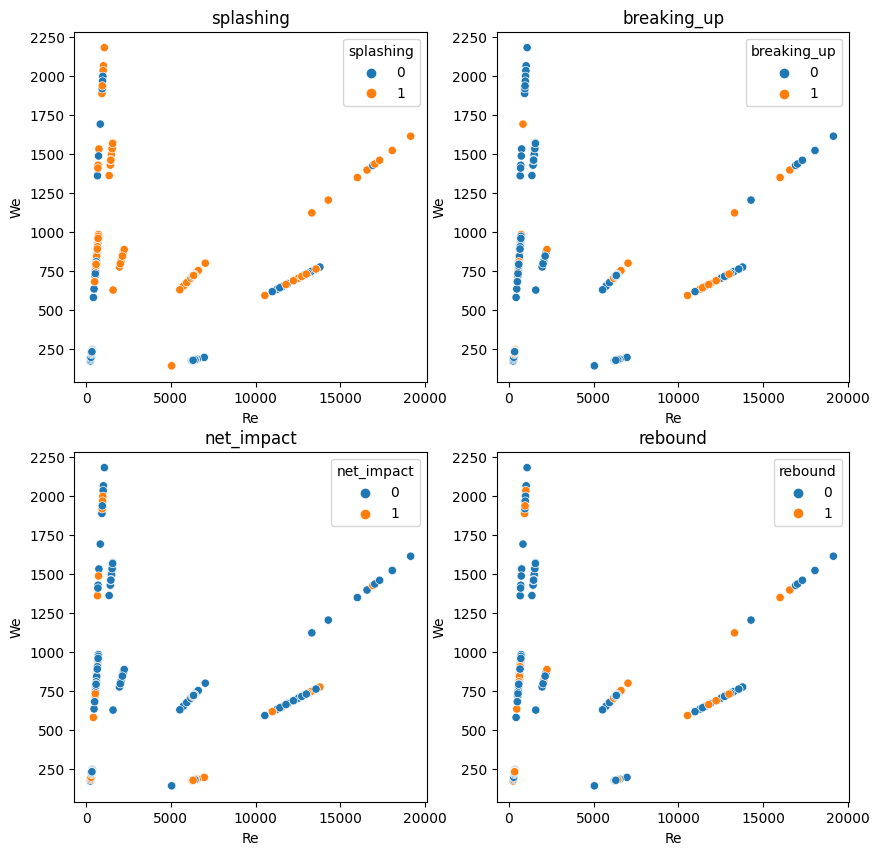

In [141]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
for target, ax in zip(target_columns, axs.ravel()):
    sns.scatterplot(data=df, x='Re', y='We', hue=target, ax=ax)
    ax.set_title(target)
plt.show()

## 5. Для признака We_Re (объединяющего We и Re, см. выше) построить:

### a. Boxplot-ы для We_Re по оси Y и splashing, breaking_up, net_impact и rebound 0-1 по оси X (всего 4 графика) 


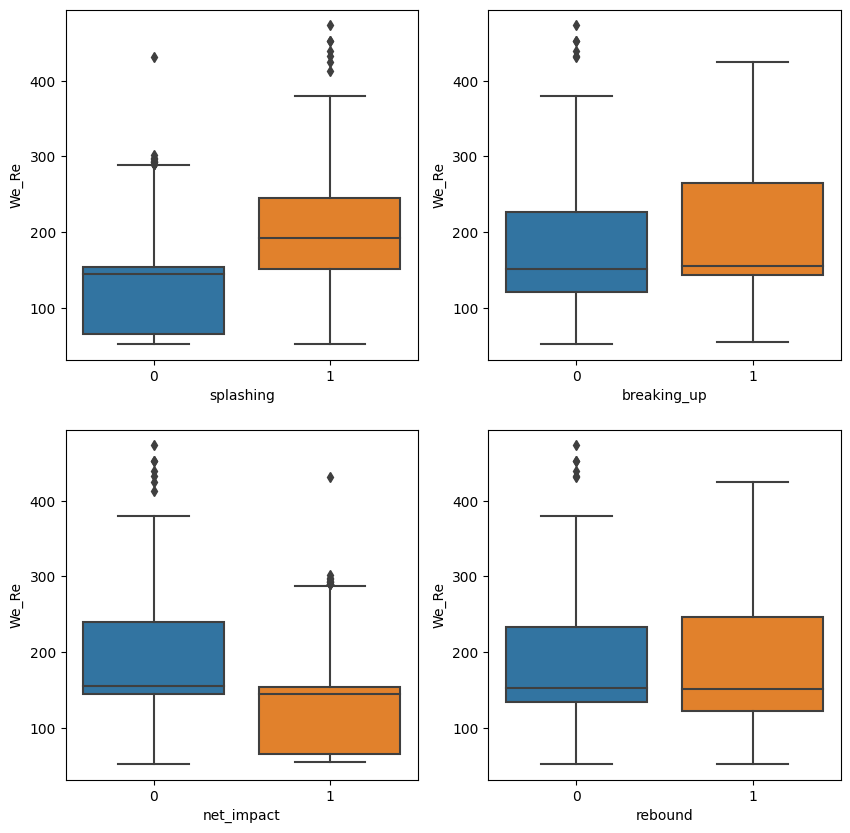

In [142]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
for target, ax in zip(target_columns, axs.ravel()):
    sns.boxplot(df, x=target, y='We_Re', ax=ax)
plt.show()

### b. Спаренные Boxplot-ы (hue=Splashing; breaking_up; net_impact; rebound) для We_Re по оси Y и inclination, volume_fraction_binary, wettability по оси X (всего 12 графиков)


In [143]:
features = ['inclination', 'volume_fraction_binary', 'wettability']

In [144]:
import itertools

combs = list(itertools.product(target_columns, features))

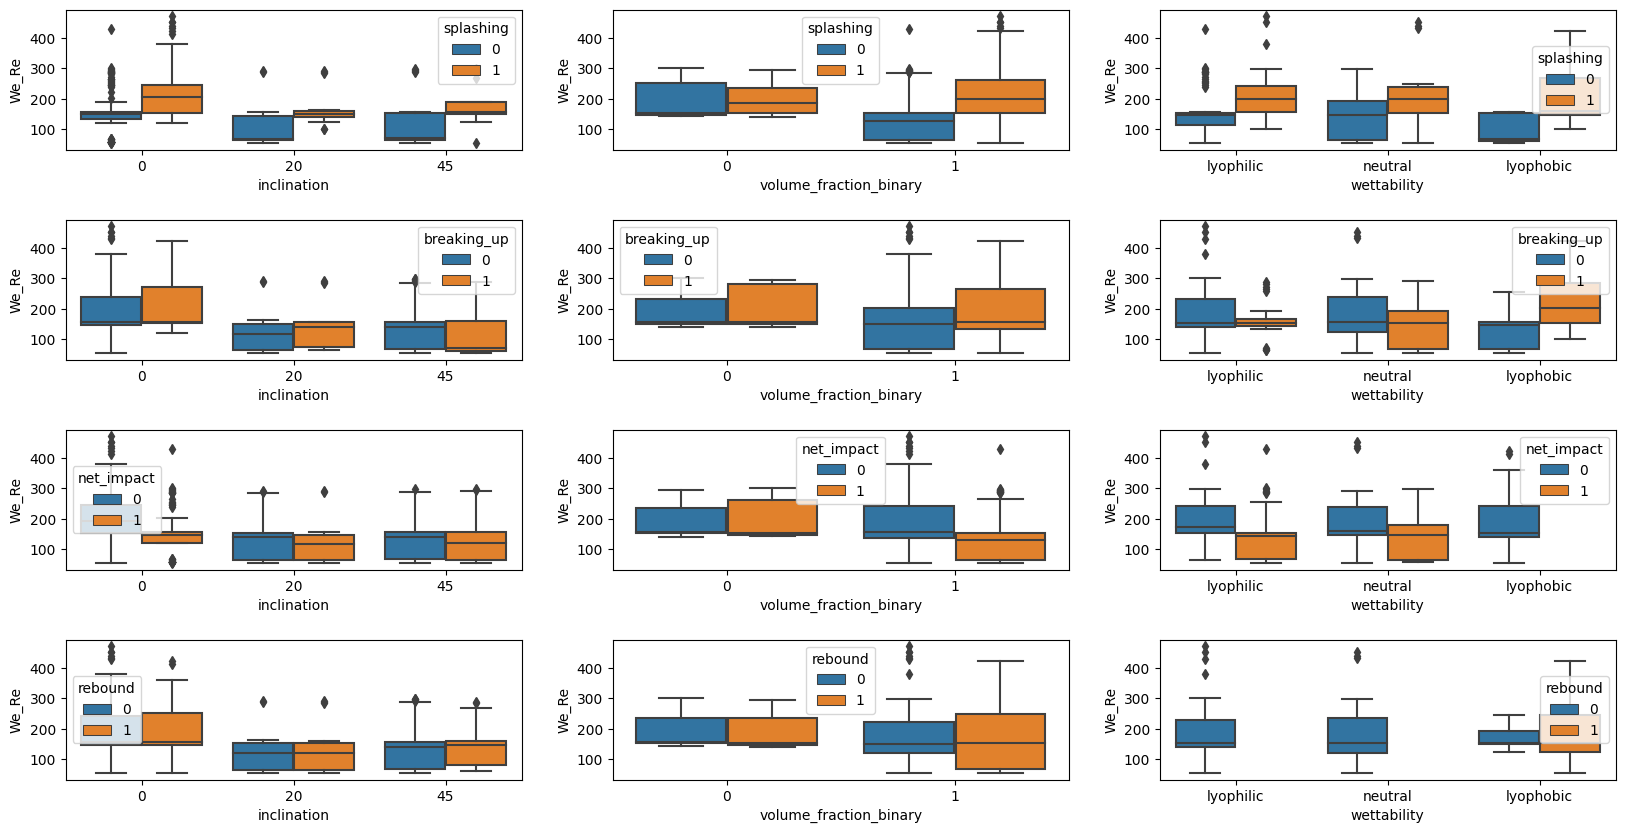

In [145]:
fig, axs = plt.subplots(4, 3, figsize=(20, 10))
plt.subplots_adjust(hspace=0.5)
for i, ax in enumerate(axs.ravel()):
    combination = combs[i]
    sns.boxplot(df, x=combination[1], y='We_Re', ax=ax, hue=combination[0])
plt.show()

### c. Спаренные Boxplot-ы (hue=Splashing; breaking_up; net_impact; rebound) для We_Re по оси Y и roughness_binary по оси X, когда wettability == lyophilic (всего 4 графика)


In [146]:
df_plot = df[
    df['wettability']=='lyophilic'
]

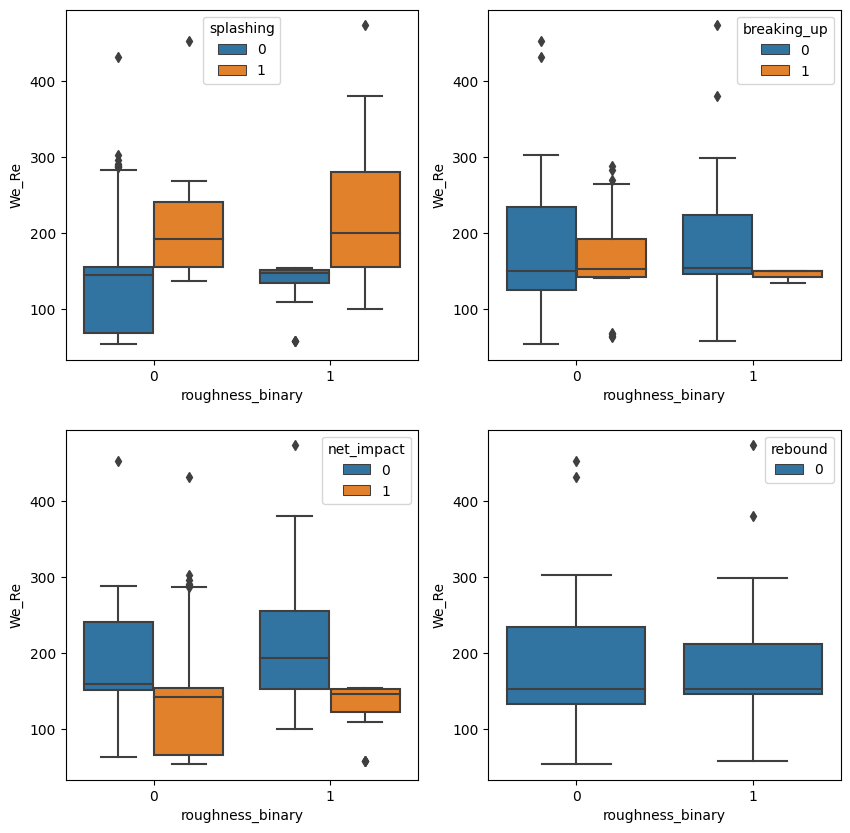

In [147]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
for target, ax in zip(target_columns, axs.ravel()):
    sns.boxplot(df_plot, x='roughness_binary', y='We_Re', ax=ax, hue=target)
plt.show()

### d. Scatterplot-ы c We_Re по оси X и particle_mean_diameter, particle_liquid_density_ratio по оси Y, воспользовавшись hue по splashing, breaking_up, net_impact, rebound (всего 8 графиков)


In [148]:
features = ['particle_mean_diameter', 'particle_liquid_density_ratio']
combs = list(itertools.product(target_columns, features))
combs

[('splashing', 'particle_mean_diameter'),
 ('splashing', 'particle_liquid_density_ratio'),
 ('breaking_up', 'particle_mean_diameter'),
 ('breaking_up', 'particle_liquid_density_ratio'),
 ('net_impact', 'particle_mean_diameter'),
 ('net_impact', 'particle_liquid_density_ratio'),
 ('rebound', 'particle_mean_diameter'),
 ('rebound', 'particle_liquid_density_ratio')]

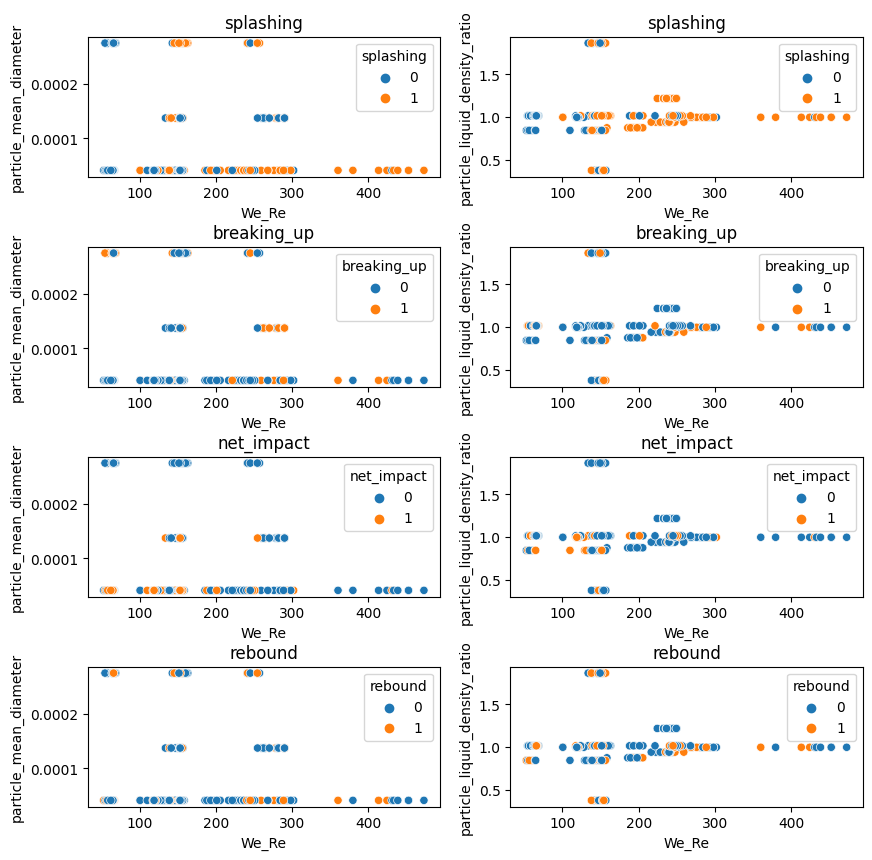

In [149]:
fig, axs = plt.subplots(4, 2, figsize=(10, 10))
plt.subplots_adjust(hspace=0.5)
for i, ax in enumerate(axs.ravel()):
    comb = combs[i]
    sns.scatterplot(data=df, x='We_Re', y=comb[1], hue=comb[0], ax=ax)
    ax.set_title(comb[0])
plt.show()

# Feature Importance

In [150]:
from sklearn.feature_selection import f_classif, chi2, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

In [151]:
def get_importance_table(target, df=df, target_columns=target_columns):
    X = df.drop(target_columns+['test'], axis=1)
    cat_columns = X.select_dtypes(include=['object']).columns
    X = pd.concat([X, pd.get_dummies(X[cat_columns])], axis=1)
    X.drop(cat_columns, inplace=True, axis=1)
    y = df[target]
    f_stats, _ = f_classif(X, y)
    chi2_stats, _ = chi2(X, y)
    mutinf_stats = mutual_info_classif(X, y)
    model = RandomForestClassifier()
    model.fit(X, y)
    feature_importances = model.feature_importances_
    df_result = pd.DataFrame(index=X.columns)
    df_result['F-test'] = f_stats
    df_result['chi-squared stats'] = chi2_stats
    df_result['Mutual Information'] = mutinf_stats
    df_result['RF feature importances'] = feature_importances
    df_result = df_result.applymap(lambda x: np.round(x, 3))
    display(HTML(f'<h1>{target}</h1>'))
    display(df_result.style.background_gradient(
        axis=0, 
        cmap='YlOrRd'
    ))

In [152]:
for target in target_columns:
    get_importance_table(target)

,F-test,chi-squared stats,Mutual Information,RF feature importances
one_drop,0.003000,0.001000,0.028000,0.010000
voltage,2.169000,0.225000,0.000000,0.040000
long_impulse_duration,9.947000,3.129000,0.023000,0.015000
height,49.802000,9.402000,0.116000,0.032000
inclination,9.166000,246.375000,0.000000,0.024000
droplet_diameter,0.024000,0.000000,0.006000,0.063000
liquid_density,32.240000,264.567000,0.122000,0.027000
surface_tension,14.865000,0.019000,0.107000,0.019000
viscosity,34.831000,0.197000,0.130000,0.034000
particle_mean_diameter,0.469000,0.000000,0.014000,0.012000


,F-test,chi-squared stats,Mutual Information,RF feature importances
one_drop,5.781000,1.784000,0.000000,0.019000
voltage,5.724000,0.587000,0.014000,0.067000
long_impulse_duration,1.113000,0.358000,0.000000,0.021000
height,0.322000,0.069000,0.005000,0.010000
inclination,0.036000,0.982000,0.043000,0.019000
droplet_diameter,4.954000,0.000000,0.015000,0.075000
liquid_density,0.339000,3.017000,0.056000,0.014000
surface_tension,11.340000,0.014000,0.011000,0.019000
viscosity,4.052000,0.025000,0.055000,0.024000
particle_mean_diameter,11.394000,0.001000,0.000000,0.023000


,F-test,chi-squared stats,Mutual Information,RF feature importances
one_drop,0.170000,0.053000,0.006000,0.008000
voltage,0.583000,0.061000,0.000000,0.046000
long_impulse_duration,2.862000,0.917000,0.041000,0.019000
height,15.456000,3.178000,0.031000,0.013000
inclination,0.825000,22.684000,0.001000,0.022000
droplet_diameter,0.057000,0.000000,0.000000,0.061000
liquid_density,4.833000,42.564000,0.057000,0.017000
surface_tension,8.521000,0.011000,0.048000,0.012000
viscosity,3.896000,0.024000,0.054000,0.016000
particle_mean_diameter,15.542000,0.001000,0.059000,0.021000


,F-test,chi-squared stats,Mutual Information,RF feature importances
one_drop,4.264000,1.322000,0.000000,0.008000
voltage,0.413000,0.043000,0.000000,0.016000
long_impulse_duration,0.253000,0.082000,0.024000,0.007000
height,0.343000,0.073000,0.000000,0.004000
inclination,0.040000,1.106000,0.000000,0.003000
droplet_diameter,1.640000,0.000000,0.000000,0.028000
liquid_density,0.490000,4.369000,0.000000,0.008000
surface_tension,8.444000,0.011000,0.011000,0.007000
viscosity,0.302000,0.002000,0.048000,0.004000
particle_mean_diameter,0.024000,0.000000,0.000000,0.002000
